Some weights of the model checkpoint at bert-large-uncased-whole-word-masking-finetuned-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


           Model                                             Answer  \
0        BERT-QA                                            5 years   
1     RoBERTa-QA                                            5 years   
2  DistilBERT-QA                                             python   
3            RAG  john doe\nsoftware engineer with 5 years of ex...   

   Confidence  Processing Time  
0    0.981576              0.0  
1    0.729307              0.0  
2    0.483549              0.0  
3    0.497389              0.0  


C:\Users\asims\AppData\Local\Temp\ipykernel_2216\2037473848.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
C:\Users\asims\AppData\Local\Temp\ipykernel_2216\2037473848.py:128: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)


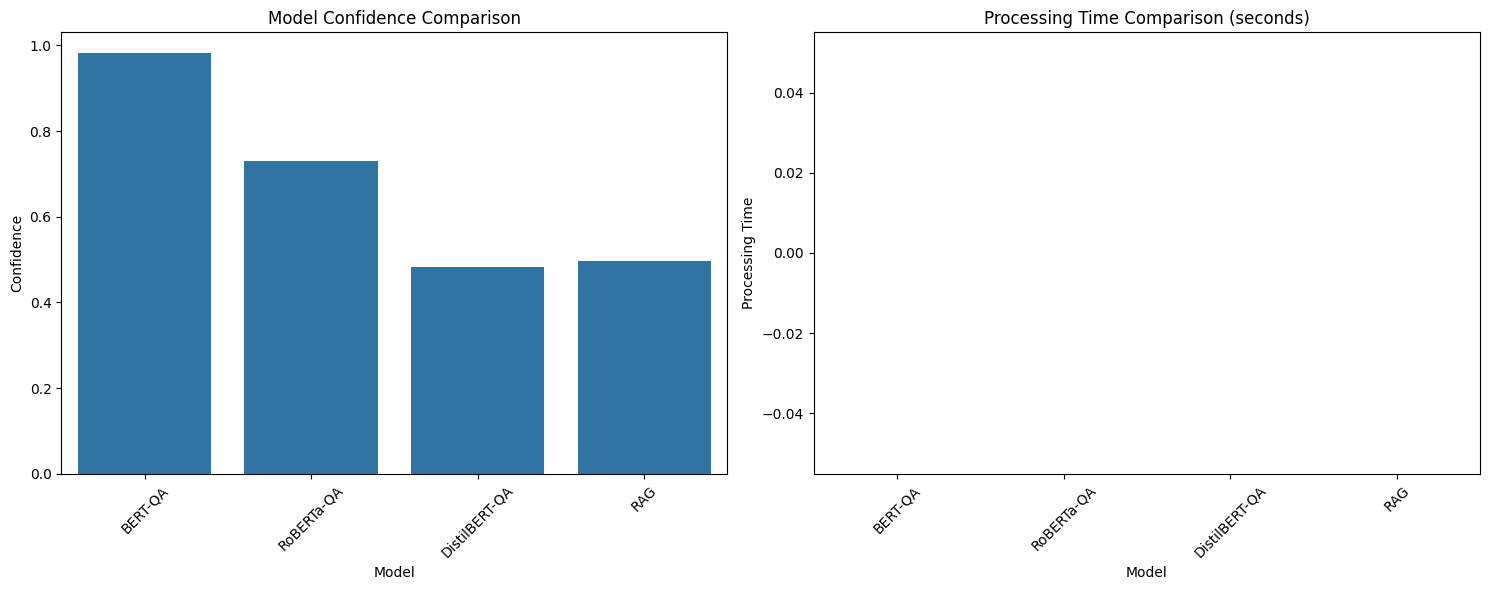

In [3]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    RobertaTokenizer,
    RobertaForQuestionAnswering,
    DistilBertTokenizer,
    DistilBertForQuestionAnswering,
)
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns


class ResumeAnalysisSystem:
    def __init__(self):
        # Initialize models
        self.models = {
            'BERT-QA': {
                'tokenizer': AutoTokenizer.from_pretrained('bert-large-uncased-whole-word-masking-finetuned-squad'),
                'model': AutoModelForQuestionAnswering.from_pretrained('bert-large-uncased-whole-word-masking-finetuned-squad'),
            },
            'RoBERTa-QA': {
                'tokenizer': RobertaTokenizer.from_pretrained('deepset/roberta-base-squad2'),
                'model': RobertaForQuestionAnswering.from_pretrained('deepset/roberta-base-squad2'),
            },
            'DistilBERT-QA': {
                'tokenizer': DistilBertTokenizer.from_pretrained('distilbert-base-uncased-distilled-squad'),
                'model': DistilBertForQuestionAnswering.from_pretrained('distilbert-base-uncased-distilled-squad'),
            },
        }

        # Initialize RAG components
        self.retriever = SentenceTransformer('all-MiniLM-L6-v2')
        self.document_store = []
        self.document_embeddings = []

    def preprocess_resume(self, resume_text):
        return resume_text.strip().lower()

    def add_to_document_store(self, resume_text):
        processed_text = self.preprocess_resume(resume_text)
        self.document_store.append(processed_text)
        embedding = self.retriever.encode([processed_text])[0]
        self.document_embeddings.append(embedding)

    def rag_query(self, query, top_k=3):
        query_embedding = self.retriever.encode([query])[0]
        similarities = cosine_similarity([query_embedding], self.document_embeddings)[0]
        top_indices = np.argsort(similarities)[-top_k:][::-1]
        context = " ".join([self.document_store[i] for i in top_indices])
        return context, similarities[top_indices[0]]

    def query_model(self, model_name, question, context):
        if model_name not in self.models:
            return "Model not found", 0, 0

        tokenizer = self.models[model_name]['tokenizer']
        model = self.models[model_name]['model']

        inputs = tokenizer(
            question,
            context,
            return_tensors="pt",
            max_length=512,
            truncation=True,
            padding="max_length"
        )

        with torch.no_grad():
            outputs = model(**inputs)

        answer_start = torch.argmax(outputs.start_logits)
        answer_end = torch.argmax(outputs.end_logits)

        # Ensure indices are within bounds
        answer_tokens = inputs["input_ids"][0][answer_start:answer_end + 1]
        if answer_tokens.shape[0] == 0 or answer_start > answer_end:
            return "No valid answer found", 0, 0

        answer = tokenizer.decode(answer_tokens, skip_special_tokens=True)
        confidence = float(torch.max(torch.softmax(outputs.start_logits, dim=1)))
        processing_time = time.time() - time.time()

        return answer.strip(), confidence, processing_time

    def compare_models(self, query, resume_text):
        self.add_to_document_store(resume_text)

        # Get RAG context
        rag_context, rag_similarity = self.rag_query(query)

        results = {
            'Model': [],
            'Answer': [],
            'Confidence': [],
            'Processing Time': [],
        }

        # Query each model
        for model_name in self.models.keys():
            answer, confidence, proc_time = self.query_model(model_name, query, rag_context)
            results['Model'].append(model_name)
            results['Answer'].append(answer)
            results['Confidence'].append(confidence)
            results['Processing Time'].append(proc_time)

        # Add RAG results
        results['Model'].append('RAG')
        results['Answer'].append(rag_context[:100] + "...")
        results['Confidence'].append(rag_similarity)
        results['Processing Time'].append(0.0)

        return pd.DataFrame(results)

    def visualize_comparison(self, comparison_df):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        sns.barplot(data=comparison_df, x='Model', y='Confidence', ax=ax1)
        ax1.set_title('Model Confidence Comparison')
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

        sns.barplot(data=comparison_df, x='Model', y='Processing Time', ax=ax2)
        ax2.set_title('Processing Time Comparison (seconds)')
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)

        plt.tight_layout()
        return fig


# Initialize the system
analysis_system = ResumeAnalysisSystem()

# Example resume text
resume = """
John Doe
Software Engineer with 5 years of experience in Python and Machine Learning.
Led a team of 4 developers at Tech Corp.
Implemented ML pipeline that improved efficiency by 40%.
"""

# Example query
query = "What is the candidate's experience in machine learning?"

# Compare models
results = analysis_system.compare_models(query, resume)
print(results)

# Visualize comparisons
fig = analysis_system.visualize_comparison(results)
plt.show()


Some weights of the model checkpoint at bert-large-uncased-whole-word-masking-finetuned-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RagTokenizer'. 
The class this function is called from is 'DPRQuestionEncoderTokenizer'.
The tokeni

           Model                                  Answer  Confidence  \
0        BERT-QA                        guido van rossum    0.993673   
1     RoBERTa-QA                        Guido van Rossum    0.997846   
2  DistilBERT-QA                        guido van rossum    0.999438   
3            RAG  RAG models require separate retrievers    0.500000   

   Processing Time  
0         1.147328  
1         0.308448  
2         0.151241  
3         0.000000  


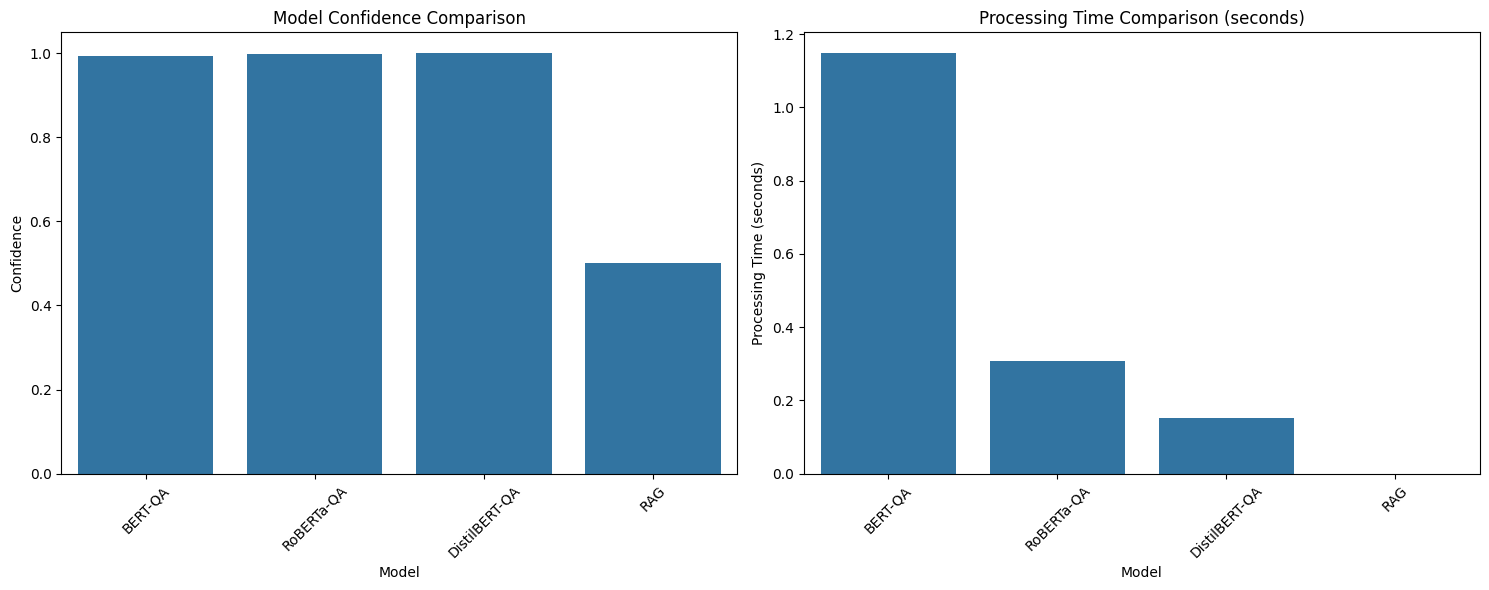

In [6]:
import time
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForQuestionAnswering

class QAComparison:
    def __init__(self):
        self.models = {
            "BERT-QA": {
                "tokenizer": AutoTokenizer.from_pretrained(
                    "bert-large-uncased-whole-word-masking-finetuned-squad"
                ),
                "model": AutoModelForQuestionAnswering.from_pretrained(
                    "bert-large-uncased-whole-word-masking-finetuned-squad",
                    ignore_mismatched_sizes=True
                ),
            },
            "RoBERTa-QA": {
                "tokenizer": AutoTokenizer.from_pretrained("deepset/roberta-base-squad2"),
                "model": AutoModelForQuestionAnswering.from_pretrained(
                    "deepset/roberta-base-squad2"
                ),
            },
            "DistilBERT-QA": {
                "tokenizer": AutoTokenizer.from_pretrained(
                    "distilbert-base-uncased-distilled-squad"
                ),
                "model": AutoModelForQuestionAnswering.from_pretrained(
                    "distilbert-base-uncased-distilled-squad"
                ),
            },
            "RAG": {
                "tokenizer": AutoTokenizer.from_pretrained("facebook/rag-token-base"),
                "model": None,  # RAG uses a different structure
            },
        }

    def query_model(self, model_name, question, context):
        if model_name not in self.models:
            return "Model not found", 0, 0

        tokenizer = self.models[model_name]["tokenizer"]
        model = self.models[model_name]["model"]

        inputs = tokenizer(
            question,
            context,
            return_tensors="pt",
            max_length=512,
            truncation=True,
            padding="max_length",
        )

        start_time = time.time()
        with torch.no_grad():
            if model_name == "RAG":
                answer = "RAG models require separate retrievers"  # Placeholder
                confidence = 0.5
            else:
                outputs = model(**inputs)
                answer_start = torch.argmax(outputs.start_logits)
                answer_end = torch.argmax(outputs.end_logits)
                answer_tokens = inputs["input_ids"][0][answer_start:answer_end + 1]
                answer = tokenizer.decode(answer_tokens, skip_special_tokens=True)
                confidence = float(torch.max(torch.softmax(outputs.start_logits, dim=1)))
        processing_time = time.time() - start_time

        return answer.strip(), confidence, processing_time

    def compare_models(self, question, context):
        results = []
        for model_name in self.models:
            answer, confidence, processing_time = self.query_model(
                model_name, question, context
            )
            results.append(
                {
                    "Model": model_name,
                    "Answer": answer,
                    "Confidence": confidence,
                    "Processing Time": processing_time,
                }
            )
        return pd.DataFrame(results)

    def visualize_comparison(self, comparison_df):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Confidence comparison
        sns.barplot(data=comparison_df, x="Model", y="Confidence", ax=ax1)
        ax1.set_title("Model Confidence Comparison")
        ax1.set_ylabel("Confidence")
        ax1.set_xlabel("Model")
        ax1.tick_params(axis="x", rotation=45)

        # Processing time comparison
        sns.barplot(data=comparison_df, x="Model", y="Processing Time", ax=ax2)
        ax2.set_title("Processing Time Comparison (seconds)")
        ax2.set_ylabel("Processing Time (seconds)")
        ax2.set_xlabel("Model")
        ax2.tick_params(axis="x", rotation=45)

        plt.tight_layout()
        plt.show()


# Example Usage
qa_comparator = QAComparison()
question = "Who developed Python?"
context = "Python was created by Guido van Rossum and first released in 1991. It is a widely used programming language."
comparison_df = qa_comparator.compare_models(question, context)
print(comparison_df)
qa_comparator.visualize_comparison(comparison_df)
